# ARBOLES DE DECISIÓN

Los árboles de decisión (DT) son un método de **aprendizaje supervisado no paramétrico** utilizado para **clasificación y regresión.** El objetivo es crear un modelo que prediga el valor de un variable objetivo mediante el aprendizaje de reglas de decisión simples inferidas de los datos Funciones. Un árbol puede verse como una aproximación constante a trozos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
titanic_df = sns.load_dataset('titanic')
titanic_df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


# EDA

In [3]:
titanic_df.dtypes.value_counts()

object      5
int64       4
float64     2
bool        2
category    1
category    1
dtype: int64

In [4]:
titanic_df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [5]:
columns_to_drop = ['fare','embarked','class','who','adult_male','deck','embark_town','alive','alone']
titanic_df.drop(columns_to_drop,axis='columns',inplace=True)
titanic_df

,survived,pclass,sex,age,sibsp,parch
0,0,3,male,22.0,1,0
1,1,1,female,38.0,1,0
2,1,3,female,26.0,0,0
3,1,1,female,35.0,1,0
4,0,3,male,35.0,0,0
...,...,...,...,...,...,...
886,0,2,male,27.0,0,0
887,1,1,female,19.0,0,0
888,0,3,female,NaN,1,2
889,1,1,male,26.0,0,0


In [6]:
titanic_df.shape

(891, 6)

In [7]:
titanic_df.dropna()

,survived,pclass,sex,age,sibsp,parch
0,0,3,male,22.0,1,0
1,1,1,female,38.0,1,0
2,1,3,female,26.0,0,0
3,1,1,female,35.0,1,0
4,0,3,male,35.0,0,0
...,...,...,...,...,...,...
885,0,3,female,39.0,0,5
886,0,2,male,27.0,0,0
887,1,1,female,19.0,0,0
889,1,1,male,26.0,0,0


In [8]:
titanic_df.isna().sum()

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
dtype: int64


DataFrame resultante:


,survived,pclass,age,sibsp,parch,sex_male
0,0,3,22.0,1,0,1
1,1,1,38.0,1,0,0
2,1,3,26.0,0,0,0
3,1,1,35.0,1,0,0
4,0,3,35.0,0,0,1


0

None

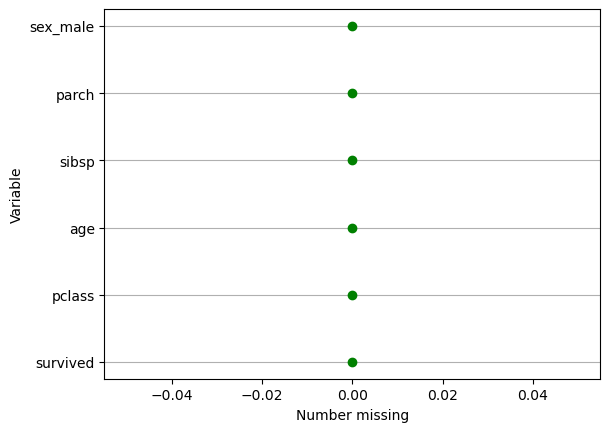

In [12]:
#Paso2: Ejecutamos pandas Missing extensión notebook
%run "D:\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Dia_4\pandas_missing_extension.ipynb"

# Aplicamos la función recursiva
titanic_df = imputar_recursivo(titanic_df.copy())

print("\nDataFrame resultante:")
display(titanic_df.head(5))
display(titanic_df.missing.number_missing())
display(titanic_df.missing.missing_variable_plot())


# CODIFICACIÓN DE VARIABLES CATEGORICAS

In [13]:
titanic_df.dtypes

survived      int64
pclass        int64
age         float64
sibsp         int64
parch         int64
sex_male      uint8
dtype: object

In [15]:
titanic_df = pd.get_dummies(titanic_df,columns=['sex_male'],drop_first=True)
titanic_df.head()

,survived,pclass,age,sibsp,parch,sex_male_1
0,0,3,22.0,1,0,1
1,1,1,38.0,1,0,0
2,1,3,26.0,0,0,0
3,1,1,35.0,1,0,0
4,0,3,35.0,0,0,1


In [16]:
titanic_df['sex_male_1'] = titanic_df['sex_male_1'].astype(int)
titanic_df.rename(columns = {'sex_male_1':'sex'},inplace=True)
titanic_df.head(10)

,survived,pclass,age,sibsp,parch,sex
0,0,3,22.000000,1,0,1
1,1,1,38.000000,1,0,0
2,1,3,26.000000,0,0,0
3,1,1,35.000000,1,0,0
4,0,3,35.000000,0,0,1
5,0,3,29.699118,0,0,1
6,0,1,54.000000,0,0,1
7,0,3,2.000000,3,1,1
8,1,3,27.000000,0,2,0
9,1,2,14.000000,1,0,0


# ENTRENAMIENTO USANDO ARBOLES DE DECISIÓN

## PASO 1 - DEFINIMOS VARIABLES

In [17]:
X = titanic_df.drop("survived",axis=1)
y = titanic_df['survived']

## PASO 2 - DIVIDIMOS DATASET EN ENTRENAMIENTO Y TEST

In [18]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=00000)

## PASO 3 - CREAR EL MODELO DE ARBOL DE DECISIÓN

In [3]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier()

## PASO 4 - ENTRENAMOS EL MODELO

In [20]:
tree.fit(X_train,y_train)

DecisionTreeClassifier()

# EVALUAMOS EL MODELO

In [21]:
from sklearn.metrics import accuracy_score

y_pred = tree.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)

print(f'Accuracy : {accuracy}')

Accuracy : 0.7932960893854749


[Text(0.5, 0.9166666666666666, 'x[1] <= 0.8\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.4090909090909091, 0.75, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.5909090909090909, 0.75, 'x[1] <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.36363636363636365, 0.5833333333333334, 'x[0] <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.18181818181818182, 0.4166666666666667, 'x[1] <= 1.65\ngini = 0.041\nsamples = 48\nvalue = [0, 47, 1]'),
 Text(0.09090909090909091, 0.25, 'gini = 0.0\nsamples = 47\nvalue = [0, 47, 0]'),
 Text(0.2727272727272727, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.5454545454545454, 0.4166666666666667, 'x[1] <= 1.55\ngini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.45454545454545453, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.6363636363636364, 0.25, 'x[0] <= 5.45\ngini = 0.444\nsamples = 3\nvalue = [0, 2, 1]'),
 Text(0.5454545454545454, 0.08333333333333333, 'gini = 

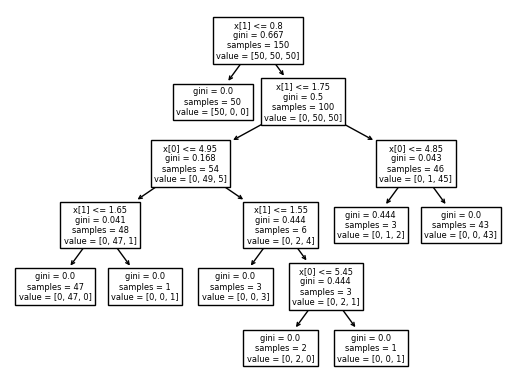

In [18]:
from sklearn import tree
clf=tree.DecisionTreeClassifier()
clf = clf.fit(X, y)
tree.plot_tree(clf)

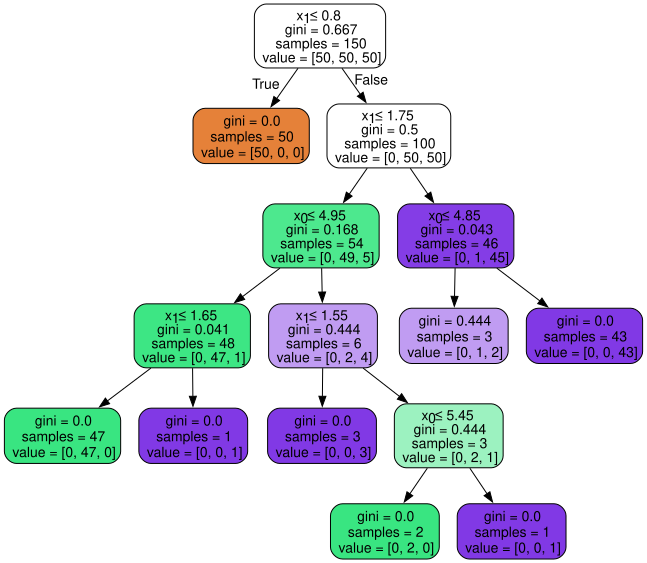

In [28]:
import graphviz
dot_data = tree.export_graphviz(clf, out_file=None, 
                     #feature_names=iris.feature_names,  
                     #class_names=iris.target_names,  
                     filled=True, rounded=True,  
                     special_characters=True)  
graph = graphviz.Source(dot_data)  
graph 